# Heart Disease Classification - FAST VERSION
## SFLA-Optimized Cost-Sensitive AdaBoost (بدون Random Subspace)

**توجه:** پارامترها برای اجرای سریع در کمتر از ۵ دقیقه کاهش یافته‌اند.

In [12]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix,
)

BASE_RANDOM_STATE = 42
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

INCLUDE_DATASET_COLUMN = False

# ============================================================
# تنظیمات سبک‌شده برای اجرای سریع
# ============================================================
REPEATS = 10                     # قبلاً 10 بود
SFLA_POPULATION = 50            # قبلاً 50 بود
SFLA_MEMEPLEXES = 3             # قبلاً 5 بود
SFLA_LOCAL_ITERS = 10            # قبلاً 10 بود
SFLA_GENERATIONS = 30            # قبلاً 30 بود
CV_SPLITS_TUNING = 5            # قبلاً 5 بود
MIN_SPECIFICITY = 0.70
SPECIFICITY_PENALTY_WEIGHT = 5.0

print("تنظیمات اعمال شد.")

تنظیمات اعمال شد.


In [13]:
DATA_PATH = os.environ.get("HEART_CSV_PATH", "heart_disease_uci.csv")
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.drop(columns=["id"])
df_raw["target"] = (df_raw["num"] > 0).astype(int)
df_raw = df_raw.drop(columns=["num"])

numeric_features = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
binary_features = ["sex", "fbs", "exang"]
nominal_features = ["cp", "restecg", "slope", "thal"]
if INCLUDE_DATASET_COLUMN:
    nominal_features = nominal_features + ["dataset"]
else:
    df_raw = df_raw.drop(columns=["dataset"])

X_all = df_raw.drop(columns=["target"])
y_all = df_raw["target"]
for col in binary_features:
    X_all[col] = X_all[col].astype("object")

print("اندازه‌ی کل دیتاست:", X_all.shape, "| توزیع هدف:", dict(y_all.value_counts()))

اندازه‌ی کل دیتاست: (920, 13) | توزیع هدف: {1: np.int64(509), 0: np.int64(411)}


In [14]:
def make_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, binary_features + nominal_features),
    ])

def make_pipeline(classifier):
    return Pipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("clf", classifier),
    ])

print("Preprocessor آماده است.")

Preprocessor آماده است.


In [15]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
    }

def composite_fitness_from_predictions(y_true, y_pred):
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    score = f1
    if spec < MIN_SPECIFICITY:
        score -= SPECIFICITY_PENALTY_WEIGHT * (MIN_SPECIFICITY - spec)
    return score

print("معیارهای ارزیابی آماده هستند.")

معیارهای ارزیابی آماده هستند.


In [16]:
class ImprovedCostSensitiveAdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=50, learning_rate_init=1.0, decay_rate=0.0,
                 max_depth=1, cost_fn=1.0, cost_fp=1.0,
                 random_state=BASE_RANDOM_STATE):
        self.n_estimators = n_estimators
        self.learning_rate_init = learning_rate_init
        self.decay_rate = decay_rate
        self.max_depth = max_depth
        self.cost_fn = cost_fn
        self.cost_fp = cost_fp
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples = X.shape[0]

        rng = np.random.RandomState(self.random_state or 0)

        y_mod = np.where(y == 0, -1, 1)
        costs = np.where(y_mod == 1, self.cost_fn, self.cost_fp)
        w = np.ones(n_samples) / n_samples

        self.alphas_ = []
        self.models_ = []

        for m in range(self.n_estimators):
            model = DecisionTreeClassifier(
                max_depth=self.max_depth,
                random_state=(self.random_state or 0) + m,
            )
            model.fit(X, y_mod, sample_weight=w * costs)
            predictions = model.predict(X)

            miss = (predictions != y_mod).astype(float)
            err = np.sum(w * costs * miss) / np.sum(w * costs)
            err = np.clip(err, 1e-10, 1 - 1e-10)

            lr_m = self.learning_rate_init * np.exp(-self.decay_rate * m)
            alpha = lr_m * 0.5 * np.log((1 - err) / err)

            w *= np.exp(-alpha * y_mod * predictions * costs)
            w /= np.sum(w)

            self.alphas_.append(alpha)
            self.models_.append(model)

            if err < 1e-8:
                break

        return self

    def decision_function(self, X):
        X = np.asarray(X)
        final = np.zeros(X.shape[0])
        for alpha, model in zip(self.alphas_, self.models_):
            final += alpha * model.predict(X)
        return final

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0, 1, 0)

print("کلاس ImprovedCostSensitiveAdaBoost تعریف شد.")

کلاس ImprovedCostSensitiveAdaBoost تعریف شد.


In [17]:
class ShuffledFrogLeapingOptimizer:
    def __init__(self, bounds, fitness_fn, population_size, n_memeplexes,
                 local_iterations, max_generations, random_state, verbose=False):
        self.bounds = np.array(bounds, dtype=float)
        self.fitness_fn = fitness_fn
        self.population_size = population_size
        self.n_memeplexes = n_memeplexes
        self.local_iterations = local_iterations
        self.max_generations = max_generations
        self.rng = np.random.default_rng(random_state)
        self.verbose = verbose
        self.dim = self.bounds.shape[0]
        self.history_ = []
        self.best_frog_ = None
        self.best_fitness_ = -np.inf

    def _random_frog(self):
        low, high = self.bounds[:, 0], self.bounds[:, 1]
        return low + self.rng.random(self.dim) * (high - low)

    def _clip(self, frog):
        return np.clip(frog, self.bounds[:, 0], self.bounds[:, 1])

    def optimize(self):
        population = np.array([self._random_frog() for _ in range(self.population_size)])
        fitness = np.array([self.fitness_fn(f) for f in population])

        for gen in range(self.max_generations):
            order = np.argsort(-fitness)
            population, fitness = population[order], fitness[order]

            if fitness[0] > self.best_fitness_:
                self.best_fitness_ = fitness[0]
                self.best_frog_ = population[0].copy()
            self.history_.append(self.best_fitness_)

            if self.verbose:
                print(f"    [SFLA] gen {gen + 1}/{self.max_generations}  "
                      f"best={self.best_fitness_:.4f}")

            memeplexes = [population[i::self.n_memeplexes] for i in range(self.n_memeplexes)]
            memeplex_fits = [fitness[i::self.n_memeplexes] for i in range(self.n_memeplexes)]

            new_memeplexes, new_fits = [], []
            for mp, mf in zip(memeplexes, memeplex_fits):
                mp, mf = mp.copy(), mf.copy()
                for _ in range(self.local_iterations):
                    order_mp = np.argsort(-mf)
                    mp, mf = mp[order_mp], mf[order_mp]
                    best_local, worst_local = mp[0], mp[-1]

                    step = self.rng.random(self.dim) * (best_local - worst_local)
                    candidate = self._clip(worst_local + step)
                    cand_fit = self.fitness_fn(candidate)

                    if cand_fit <= mf[-1]:
                        step2 = self.rng.random(self.dim) * (self.best_frog_ - worst_local)
                        candidate2 = self._clip(worst_local + step2)
                        cand_fit2 = self.fitness_fn(candidate2)
                        if cand_fit2 > mf[-1]:
                            candidate, cand_fit = candidate2, cand_fit2
                        else:
                            candidate = self._random_frog()
                            cand_fit = self.fitness_fn(candidate)

                    mp[-1], mf[-1] = candidate, cand_fit

                new_memeplexes.append(mp)
                new_fits.append(mf)

            population = np.concatenate(new_memeplexes, axis=0)
            fitness = np.concatenate(new_fits, axis=0)

        order = np.argsort(-fitness)
        if fitness[order[0]] > self.best_fitness_:
            self.best_fitness_ = fitness[order[0]]
            self.best_frog_ = population[order[0]].copy()

        return self.best_frog_, self.best_fitness_

def decode_frog(frog):
    return dict(
        n_estimators=int(round(np.clip(frog[0], 20, 150))),
        max_depth=int(round(np.clip(frog[1], 1, 2))),
        cost_fn=float(np.clip(frog[2], 1.0, 1.5)),
        cost_fp=1.0,
        learning_rate_init=float(np.clip(frog[3], 0.3, 1.0)),
        decay_rate=float(np.clip(frog[4], 0.0, 0.05)),
    )

BOUNDS = [
    (20, 150),      # n_estimators
    (1, 2),         # max_depth
    (1.0, 1.5),     # cost_fn
    (0.3, 1.0),     # learning_rate_init
    (0.0, 0.05),    # decay_rate
]

print("SFLA و BOUNDS آماده هستند.")

SFLA و BOUNDS آماده هستند.


In [18]:
def run_one_repeat(split_seed, sfla_seed):
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=split_seed, stratify=y_all
    )

    test_results = {}

    # مدل‌های پایه بدون GridSearch برای سرعت بیشتر
    base_models = {
        "Naive Bayes": GaussianNB(),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=split_seed),
        "SVM": SVC(kernel="rbf", random_state=split_seed),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=split_seed),
        "AdaBoost (standard)": AdaBoostClassifier(n_estimators=50, random_state=split_seed),
    }

    for name, clf in base_models.items():
        pipe = make_pipeline(clf)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        test_results[name] = evaluate(y_test, y_pred)

    def sfla_fitness(frog):
        params = decode_frog(frog)
        pipe = make_pipeline(ImprovedCostSensitiveAdaBoost(**params, random_state=sfla_seed))
        skf = StratifiedKFold(n_splits=CV_SPLITS_TUNING, shuffle=True, random_state=sfla_seed)
        fold_scores = []
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            pipe.fit(X_tr, y_tr)
            y_val_pred = pipe.predict(X_val)
            fold_scores.append(composite_fitness_from_predictions(y_val, y_val_pred))
        return float(np.mean(fold_scores))

    optimizer = ShuffledFrogLeapingOptimizer(
        bounds=BOUNDS, fitness_fn=sfla_fitness,
        population_size=SFLA_POPULATION, n_memeplexes=SFLA_MEMEPLEXES,
        local_iterations=SFLA_LOCAL_ITERS, max_generations=SFLA_GENERATIONS,
        random_state=sfla_seed, verbose=False,
    )
    best_frog, best_fitness = optimizer.optimize()
    best_params = decode_frog(best_frog)

    proposed_pipe = make_pipeline(ImprovedCostSensitiveAdaBoost(**best_params, random_state=sfla_seed))
    proposed_pipe.fit(X_train, y_train)
    y_pred_proposed = proposed_pipe.predict(X_test)
    test_results["Proposed (SFLA-tuned)"] = evaluate(y_test, y_pred_proposed)

    return test_results, best_params, best_fitness, optimizer.history_

print("تابع run_one_repeat آماده است.")

تابع run_one_repeat آماده است.


In [19]:
all_repeat_results = []
all_best_params = []
all_histories = []

print("\n" + "=" * 90)
print(f"اجرای {REPEATS} تکرار مستقل کل pipeline (Repeated Hold-out) - نسخه سبک")
print("=" * 90)

t_start_all = time.time()
for r in range(REPEATS):
    split_seed = BASE_RANDOM_STATE + r
    sfla_seed = BASE_RANDOM_STATE + 1000 + r
    t0 = time.time()
    print(f"\n--- تکرار {r + 1}/{REPEATS} (split_seed={split_seed}, sfla_seed={sfla_seed}) ---")
    res, best_params, best_fitness, history = run_one_repeat(split_seed, sfla_seed)
    elapsed = time.time() - t0
    print(f"    زمان این تکرار: {elapsed:.1f}s | بهترین پارامتر SFLA: {best_params}  "
          f"(fitness روی CV train = {best_fitness:.4f})")
    print("    Test Accuracy این تکرار -> "
          + ", ".join(f"{k}: {v['Accuracy']:.3f}" for k, v in res.items()))

    all_repeat_results.append(res)
    all_best_params.append(best_params)
    all_histories.append(history)

total_elapsed = time.time() - t_start_all
print(f"\nزمان کل {REPEATS} تکرار: {total_elapsed:.1f} ثانیه  "
      f"(میانگین {total_elapsed / REPEATS:.1f}s در هر تکرار)")


اجرای 10 تکرار مستقل کل pipeline (Repeated Hold-out) - نسخه سبک

--- تکرار 1/10 (split_seed=42, sfla_seed=1042) ---
    زمان این تکرار: 2921.7s | بهترین پارامتر SFLA: {'n_estimators': 113, 'max_depth': 2, 'cost_fn': 1.3968177342658556, 'cost_fp': 1.0, 'learning_rate_init': 0.8258190490124879, 'decay_rate': 0.028621935472654843}  (fitness روی CV train = 0.8519)
    Test Accuracy این تکرار -> Naive Bayes: 0.832, Logistic Regression: 0.842, SVM: 0.842, Random Forest: 0.848, AdaBoost (standard): 0.837, Proposed (SFLA-tuned): 0.832

--- تکرار 2/10 (split_seed=43, sfla_seed=1043) ---
    زمان این تکرار: 2120.2s | بهترین پارامتر SFLA: {'n_estimators': 81, 'max_depth': 2, 'cost_fn': 1.207370831610339, 'cost_fp': 1.0, 'learning_rate_init': 0.4291816317247686, 'decay_rate': 0.024396826840923508}  (fitness روی CV train = 0.8450)
    Test Accuracy این تکرار -> Naive Bayes: 0.848, Logistic Regression: 0.853, SVM: 0.870, Random Forest: 0.864, AdaBoost (standard): 0.848, Proposed (SFLA-tuned): 0.859

In [23]:
model_names = list(all_repeat_results[0].keys())
metric_names = list(all_repeat_results[0][model_names[0]].keys())

summary_rows = []
for name in model_names:
    row = {"Model": name}
    for metric in metric_names:
        values = [rep[name][metric] for rep in all_repeat_results]
        row[f"{metric}_mean"] = np.mean(values)
        row[f"{metric}_std"] = np.std(values)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model").round(4)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "final_summary.csv"))

raw_rows = []
for r, rep in enumerate(all_repeat_results):
    for name, m in rep.items():
        raw_rows.append({"repeat": r + 1, "model": name, **m})
raw_df = pd.DataFrame(raw_rows).round(4)
raw_df.to_csv(os.path.join(OUTPUT_DIR, "final_raw.csv"), index=False)

best_params_df = pd.DataFrame(all_best_params)
best_params_df.insert(0, "repeat", range(1, REPEATS + 1))
best_params_df.to_csv(os.path.join(OUTPUT_DIR, "final_sfla_best_params.csv"), index=False)

print("\n" + "=" * 120)
print(f"جدول خلاصه ({REPEATS} تکرار) - میانگین ± انحراف معیار")
print("=" * 120)
print(f"{'مدل':<28}{'Accuracy':<18}{'Precision':<18}{'Sensitivity':<18} "
      f"{'Specificity':<18}{'F1':<16}{'F2':<16}")
print("-" * 120)
for name in model_names:
    row = summary_df.loc[name]
    print(f"{name:<28} "
          f"{row['Accuracy_mean']:.3f}±{row['Accuracy_std']:.3f}      "
          f"{row['Precision_mean']:.3f}±{row['Precision_std']:.3f}      "
          f"{row['Sensitivity_mean']:.3f}±{row['Sensitivity_std']:.3f}      "
          f"{row['Specificity_mean']:.3f}±{row['Specificity_std']:.3f}      "
          f"{row['F1_mean']:.3f}±{row['F1_std']:.3f}    "
          f"{row['F2_mean']:.3f}±{row['F2_std']:.3f}")

print("\nپارامترهای بهینه‌ی SFLA در هر تکرار:")
print(best_params_df.round(3).to_string(index=False))


جدول خلاصه (10 تکرار) - میانگین ± انحراف معیار
مدل                         Accuracy          Precision         Sensitivity        Specificity       F1              F2              
------------------------------------------------------------------------------------------------------------------------
Naive Bayes                  0.818±0.018      0.840±0.011      0.829±0.036      0.804±0.018      0.834±0.019    0.831±0.029
Logistic Regression          0.828±0.024      0.834±0.016      0.862±0.037      0.787±0.022      0.847±0.023    0.856±0.031
SVM                          0.841±0.019      0.835±0.015      0.889±0.034      0.780±0.025      0.861±0.018    0.877±0.027
Random Forest                0.836±0.025      0.837±0.023      0.876±0.030      0.787±0.033      0.856±0.023    0.868±0.026
AdaBoost (standard)          0.823±0.019      0.839±0.013      0.842±0.035      0.799±0.020      0.840±0.019    0.841±0.028
Proposed (SFLA-tuned)        0.834±0.023      0.836±0.021      0.872±0.034   

In [24]:
print("\n" + "=" * 90)
print("تست آماری Wilcoxon Signed-Rank (Proposed vs هر مدل پایه)")
print("=" * 90)

proposed_accs = np.array([rep["Proposed (SFLA-tuned)"]["Accuracy"] for rep in all_repeat_results])

for name in model_names:
    if name == "Proposed (SFLA-tuned)":
        continue
    other_accs = np.array([rep[name]["Accuracy"] for rep in all_repeat_results])
    diff = proposed_accs - other_accs
    if np.all(diff == 0):
        print(f"  Proposed vs {name}: تفاوت صفر (قابل محاسبه نیست)")
        continue
    try:
        stat, p_value = wilcoxon(diff)
        significant = "✓ معنادار" if p_value < 0.05 else "✗ غیرمعنادار"
        print(f"  Proposed vs {name:<25} | W={stat:.1f}, p={p_value:.4f} | {significant}")
    except Exception as e:
        print(f"  Proposed vs {name}: خطا در محاسبه ({e})")


تست آماری Wilcoxon Signed-Rank (Proposed vs هر مدل پایه)
  Proposed vs Naive Bayes               | W=5.5, p=0.0938 | ✗ غیرمعنادار
  Proposed vs Logistic Regression       | W=14.0, p=0.3555 | ✗ غیرمعنادار
  Proposed vs SVM                       | W=21.5, p=0.5703 | ✗ غیرمعنادار
  Proposed vs Random Forest             | W=27.5, p=1.0000 | ✗ غیرمعنادار
  Proposed vs AdaBoost (standard)       | W=6.0, p=0.0430 | ✓ معنادار


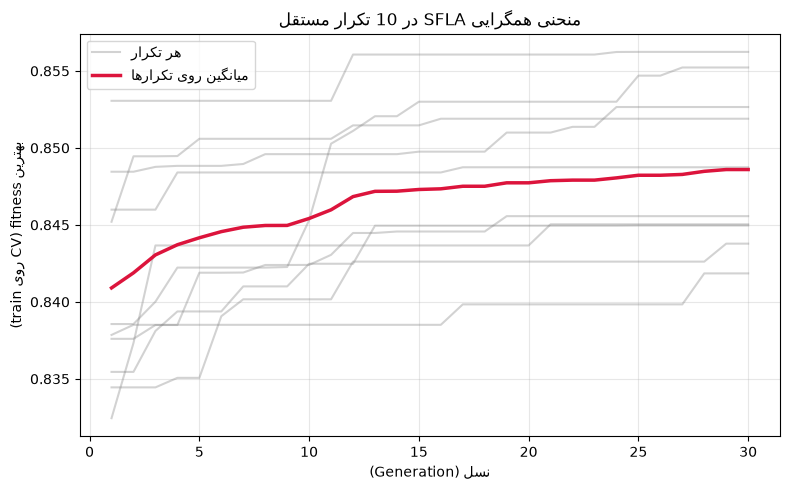


فایل‌های خروجی در 'outputs':
  - final_summary.csv
  - final_raw.csv
  - final_sfla_best_params.csv
  - final_convergence.png


In [25]:
plt.figure(figsize=(8, 5))
max_len = max(len(h) for h in all_histories)
padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in all_histories])
for r, h in enumerate(all_histories):
    plt.plot(range(1, len(h) + 1), h, alpha=0.35, color="gray",
             label="هر تکرار" if r == 0 else None)
plt.plot(range(1, max_len + 1), padded.mean(axis=0), color="crimson", linewidth=2.5,
         label="میانگین روی تکرارها")
plt.xlabel("نسل (Generation)")
plt.ylabel("بهترین fitness (CV روی train)")
plt.title(f"منحنی همگرایی SFLA در {REPEATS} تکرار مستقل")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "final_convergence.png"), dpi=300)
plt.show()

print(f"\nفایل‌های خروجی در '{OUTPUT_DIR}':")
print("  - final_summary.csv")
print("  - final_raw.csv")
print("  - final_sfla_best_params.csv")
print("  - final_convergence.png")